# Build Gemma 4 Nano ~37M Parameter SLM from Scratch

Optimized for laptop training on TinyStories while preserving all key Gemma 4 architectural innovations (except PLE, which hurts at this scale):

1. **Dual head dimensions** – head_dim=48 (sliding) vs global_head_dim=96 (full)
2. **Proportional RoPE** – partial_rotary_factor=0.25 for global layers
3. **Shared KV Cache** – last 6 layers reuse K/V from donor layers
4. **K=V Attention** – global layers share key/value projections
5. **Value Normalization** – RMSNorm (without learned scale) applied to values
6. **Logit Softcapping** – tanh-based capping at 30.0
7. **Embedding Weight Tying** – input embedding and output head share weights
8. **QK Normalization** – attention scaling=1.0 (QK norm controls magnitude)
9. **Zero-centered RMSNorm** – weights initialized to 0, applied as (1 + w)

**Key size reductions vs the 95M version:**
- emb_dim: 512 → 384 (saves ~30% per linear layer)
- n_layers: 18 → 20 (deeper for better story coherence)
- hidden_dim: 1536 → 1152
- PLE removed (saves ~15M params)
- Custom 8K tokenizer (saves ~16.2M embedding params vs GPT-2's 50K vocab)
- **Total: 95.6M → ~37M (61% smaller)**

Training on TinyStories dataset with custom SentencePiece 8K tokenizer (built by `build_tokenizer.py`).

## Step 1: Imports & Load Custom Tokenizer

**Prerequisite:** Run `python build_tokenizer.py` first to generate `tinystories_tokenizer.model`, `train.bin`, and `validation.bin`.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from tqdm.auto import tqdm
from contextlib import nullcontext
from build_tokenizer import TinyStoriesTokenizer

enc = TinyStoriesTokenizer("tinystories_tokenizer.model")

print(f"Tokenizer loaded — vocab_size: {enc.vocab_size}")
print(f"Sample: 'Once upon a time' → {enc.encode('Once upon a time')}")
print(f"Decoded back: '{enc.decode(enc.encode('Once upon a time'))}'")

Tokenizer loaded — vocab_size: 8000
Sample: 'Once upon a time' → [434, 451, 262, 399]
Decoded back: 'Once upon a time'


/Users/plakhera/Documents/gemma4/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Model Configuration (~37M parameters)

In [2]:
GEMMA4_CONFIG_54M = {
    "vocab_size": 8000,          # Custom SentencePiece tokenizer (built by build_tokenizer.py)
    "context_length": 2048,
    "emb_dim": 384,              # Narrower than 95M (was 512)
    "n_heads": 8,
    "n_layers": 20,              # Deeper than 95M (was 18) for better story coherence
    "hidden_dim": 1152,          # GeGLU intermediate size (3x emb_dim)

    # --- Dual head dimensions ---
    "head_dim": 48,              # Sliding attention layers (was 64)
    "global_head_dim": 96,       # Full attention layers (2x sliding, was 128)

    # --- Separate KV head counts ---
    "n_kv_heads": 2,             # KV heads for sliding (GQA group_size = 8/2 = 4)
    "n_global_kv_heads": 1,      # KV heads for global  (GQA group_size = 8/1 = 8)

    "qk_norm": True,

    # --- K=V for global layers ---
    "attention_k_eq_v": True,

    # --- Proportional RoPE with partial rotation ---
    "rope_local_base": 10_000.0,
    "rope_base": 1_000_000.0,
    "partial_rotary_factor": 0.25,    # 25% of 96 = 24 dims rotated for global layers

    "sliding_window": 512,

    # --- Shared KV cache ---
    "num_kv_shared_layers": 6,

    # --- PLE disabled (too expensive for <60M models) ---
    "ple_dim": 0,

    # --- Logit softcapping ---
    "final_logit_softcapping": 30.0,

    "dtype": torch.bfloat16,
    # 3 groups of (5 sliding + 1 full) + 2 extra sliding = 20 layers
    "layer_types": [
        "sliding_attention", "sliding_attention", "sliding_attention",
        "sliding_attention", "sliding_attention", "full_attention",       # group 1
        "sliding_attention", "sliding_attention", "sliding_attention",
        "sliding_attention", "sliding_attention", "full_attention",       # group 2
        "sliding_attention", "sliding_attention", "sliding_attention",
        "sliding_attention", "sliding_attention", "full_attention",       # group 3
        "sliding_attention", "sliding_attention",                         # extra depth
    ],
}

print(f"Config loaded: {GEMMA4_CONFIG_54M['n_layers']} layers, emb_dim={GEMMA4_CONFIG_54M['emb_dim']}")
print(f"Layer pattern: {GEMMA4_CONFIG_54M['layer_types']}")

Config loaded: 20 layers, emb_dim=384
Layer pattern: ['sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'full_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'full_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'sliding_attention', 'full_attention', 'sliding_attention', 'sliding_attention']


## Step 3: Rotary Position Embeddings (RoPE)

- **Standard RoPE** for sliding layers: all dims rotated, theta=10K
- **Proportional RoPE** for global layers: 25% dims rotated, theta=1M

In [3]:
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096,
                        partial_rotary_factor=1.0, dtype=torch.float32):
    """Precompute cos/sin tables. partial_rotary_factor < 1.0 leaves some dims unrotated."""
    rotary_dim = max(2, int(head_dim * partial_rotary_factor) // 2 * 2)  # ensure even
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, rotary_dim, 2, dtype=dtype) / rotary_dim))
    positions = torch.arange(context_length, dtype=dtype)
    angles = positions[:, None] * inv_freq[None, :]   # (context_length, rotary_dim // 2)
    return torch.cos(angles), torch.sin(angles)


def apply_rope(x, cos, sin):
    """Apply RoPE with partial rotation: rotary dims get rotation, rest passes through."""
    _, _, seq_len, _ = x.shape
    rotary_dim = cos.shape[-1] * 2

    cos = cos[:seq_len].unsqueeze(0).unsqueeze(0).to(x.dtype)
    sin = sin[:seq_len].unsqueeze(0).unsqueeze(0).to(x.dtype)

    x_rot, x_pass = x[..., :rotary_dim], x[..., rotary_dim:]

    x1 = x_rot[..., : rotary_dim // 2]
    x2 = x_rot[..., rotary_dim // 2 :]
    rotated = torch.cat((-x2, x1), dim=-1)

    cos_full = torch.cat([cos, cos], dim=-1)
    sin_full = torch.cat([sin, sin], dim=-1)
    x_rot = x_rot * cos_full + rotated * sin_full

    return torch.cat([x_rot, x_pass], dim=-1)


# Quick verification
cos_test, sin_test = compute_rope_params(head_dim=48, theta_base=10_000, context_length=512)
print(f"Standard RoPE (sliding): cos shape = {cos_test.shape}, rotary_dim = {cos_test.shape[-1]*2}")

cos_test_g, sin_test_g = compute_rope_params(head_dim=96, theta_base=1_000_000, context_length=512, partial_rotary_factor=0.25)
print(f"Proportional RoPE (global): cos shape = {cos_test_g.shape}, rotary_dim = {cos_test_g.shape[-1]*2} (out of 96)")

Standard RoPE (sliding): cos shape = torch.Size([512, 24]), rotary_dim = 48
Proportional RoPE (global): cos shape = torch.Size([512, 12]), rotary_dim = 24 (out of 96)


## Step 4: RMSNorm — Zero-centered Weights, Optional Learned Scale

In [4]:
class RMSNorm(nn.Module):
    """
    Gemma 4 RMSNorm: weight stored as zeros, applied as (1 + weight).
    Set with_scale=False for value normalization (pure normalization, no learned params).
    """
    def __init__(self, dim, eps=1e-6, with_scale=True):
        super().__init__()
        self.eps = eps
        self.with_scale = with_scale
        if with_scale:
            self.scale = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        dtype = x.dtype
        x = x.float()
        x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        if self.with_scale:
            x = x * (1.0 + self.scale.float())
        return x.to(dtype)


# Quick test
norm = RMSNorm(384)
test_input = torch.randn(2, 10, 384)
test_output = norm(test_input)
print(f"RMSNorm: input shape={test_input.shape}, output shape={test_output.shape}")
print(f"  Scale params initialized to zeros: {norm.scale[:5]}")
print(f"  Output RMS ≈ 1.0: {test_output.pow(2).mean(-1).sqrt().mean().item():.4f}")

RMSNorm: input shape=torch.Size([2, 10, 384]), output shape=torch.Size([2, 10, 384])
  Scale params initialized to zeros: tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)
  Output RMS ≈ 1.0: 1.0000


## Step 5: Grouped Query Attention

- Different `head_dim` per layer type (sliding=48, global=96)
- K=V for global layers (V reuses K projection output)
- Shared KV: later layers retrieve K/V from donor layers
- QK norm → scaling=1.0 (no 1/sqrt(d) scaling needed)
- V norm (RMSNorm without learned scale)

In [5]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.layer_idx = layer_idx
        layer_type = cfg["layer_types"][layer_idx]
        self.is_sliding = (layer_type == "sliding_attention")
        self.num_heads = cfg["n_heads"]

        if self.is_sliding:
            self.head_dim = cfg["head_dim"]
            self.num_kv_heads = cfg["n_kv_heads"]
            self.use_k_eq_v = False
        else:
            self.head_dim = cfg["global_head_dim"]
            self.num_kv_heads = cfg["n_global_kv_heads"]
            self.use_k_eq_v = cfg.get("attention_k_eq_v", False)

        self.group_size = self.num_heads // self.num_kv_heads
        self.d_out = self.num_heads * self.head_dim

        # --- Shared KV logic ---
        n_layers = cfg["n_layers"]
        n_shared = cfg.get("num_kv_shared_layers", 0)
        first_shared = n_layers - n_shared
        self.is_kv_shared = layer_idx >= first_shared > 0
        self.is_donor = False
        self.kv_donor_idx = None

        if self.is_kv_shared:
            non_shared_types = cfg["layer_types"][:first_shared]
            self.kv_donor_idx = len(non_shared_types) - 1 - non_shared_types[::-1].index(layer_type)
        elif n_shared > 0:
            non_shared_types = cfg["layer_types"][:first_shared]
            last_of_type = len(non_shared_types) - 1 - non_shared_types[::-1].index(layer_type)
            self.is_donor = (layer_idx == last_of_type)

        d_in = cfg["emb_dim"]
        dtype = cfg.get("dtype")

        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
        self.q_norm = RMSNorm(self.head_dim)

        if not self.is_kv_shared:
            self.W_key = nn.Linear(d_in, self.num_kv_heads * self.head_dim, bias=False, dtype=dtype)
            self.k_norm = RMSNorm(self.head_dim)
            self.v_norm = RMSNorm(self.head_dim, with_scale=False)
            if not self.use_k_eq_v:
                self.W_value = nn.Linear(d_in, self.num_kv_heads * self.head_dim, bias=False, dtype=dtype)

        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

    def forward(self, x, mask, cos, sin, shared_kv_states):
        b, seq_len, _ = x.shape

        queries = self.W_query(x).view(b, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        queries = self.q_norm(queries)
        queries = apply_rope(queries, cos, sin)

        if self.is_kv_shared:
            keys, values = shared_kv_states[self.kv_donor_idx]
        else:
            k_raw = self.W_key(x).view(b, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2)

            if self.use_k_eq_v:
                v_raw = k_raw
            else:
                v_raw = self.W_value(x).view(b, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2)

            keys = apply_rope(self.k_norm(k_raw), cos, sin)
            values = self.v_norm(v_raw)

            if self.is_donor:
                shared_kv_states[self.layer_idx] = (keys, values)

        keys = keys.repeat_interleave(self.group_size, dim=1)
        values = values.repeat_interleave(self.group_size, dim=1)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)
        attn_weights = torch.softmax(attn_scores.float(), dim=-1).to(queries.dtype)

        context = (attn_weights @ values).transpose(1, 2).reshape(b, seq_len, self.d_out)
        return self.out_proj(context)


print("GroupedQueryAttention defined.")
print(f"  Sliding layers: head_dim=48, n_kv_heads=2, GQA group_size=4")
print(f"  Global layers:  head_dim=96, n_kv_heads=1, GQA group_size=8, K=V enabled")

GroupedQueryAttention defined.
  Sliding layers: head_dim=48, n_kv_heads=2, GQA group_size=4
  Global layers:  head_dim=96, n_kv_heads=1, GQA group_size=8, K=V enabled


## Step 6: Feed Forward — GeGLU (Gated GeLU)

In [6]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dtype = cfg.get("dtype")
        self.gate = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], bias=False, dtype=dtype)
        self.up   = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], bias=False, dtype=dtype)
        self.down = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], bias=False, dtype=dtype)

    def forward(self, x):
        return self.down(F.gelu(self.gate(x), approximate="tanh") * self.up(x))


print("FeedForward defined.")
print(f"  GeGLU: {GEMMA4_CONFIG_54M['emb_dim']} → {GEMMA4_CONFIG_54M['hidden_dim']} → {GEMMA4_CONFIG_54M['emb_dim']}")
print(f"  Params per FFN block: {GEMMA4_CONFIG_54M['emb_dim'] * GEMMA4_CONFIG_54M['hidden_dim'] * 3:,}")

FeedForward defined.
  GeGLU: 384 → 1152 → 384
  Params per FFN block: 1,327,104


## Step 7: Transformer Block — with Optional PLE Conditioning and Layer Scalar

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.attn_type = cfg["layer_types"][layer_idx]
        emb_dim = cfg["emb_dim"]

        self.att = GroupedQueryAttention(cfg, layer_idx)
        self.ff = FeedForward(cfg)

        self.input_layernorm = RMSNorm(emb_dim)
        self.post_attention_layernorm = RMSNorm(emb_dim)
        self.pre_feedforward_layernorm = RMSNorm(emb_dim)
        self.post_feedforward_layernorm = RMSNorm(emb_dim)

        self.register_buffer("layer_scalar", torch.ones(1, dtype=cfg.get("dtype", torch.float32)))

        self.ple_dim = cfg.get("ple_dim", 0)
        if self.ple_dim > 0:
            dtype = cfg.get("dtype")
            self.ple_gate = nn.Linear(emb_dim, self.ple_dim, bias=False, dtype=dtype)
            self.ple_proj = nn.Linear(self.ple_dim, emb_dim, bias=False, dtype=dtype)
            self.post_ple_norm = RMSNorm(emb_dim)

    def forward(self, x, mask, cos, sin, shared_kv_states, per_layer_input=None):
        input_dtype = x.dtype

        shortcut = x
        x = self.input_layernorm(x)
        x = self.att(x, mask, cos, sin, shared_kv_states)
        x = self.post_attention_layernorm(x)
        x = shortcut + x

        shortcut = x
        x = self.pre_feedforward_layernorm(x)
        x = self.ff(x)
        x = self.post_feedforward_layernorm(x)
        x = shortcut + x

        if self.ple_dim > 0 and per_layer_input is not None:
            shortcut = x
            h = F.gelu(self.ple_gate(x), approximate="tanh") * per_layer_input
            h = self.ple_proj(h)
            h = self.post_ple_norm(h)
            x = shortcut + h

        return (x * self.layer_scalar).to(input_dtype)


print("TransformerBlock defined.")
print(f"  Structure: RMSNorm → Attention → RMSNorm → residual → RMSNorm → FFN → RMSNorm → residual")
print(f"  PLE: {'enabled' if GEMMA4_CONFIG_54M['ple_dim'] > 0 else 'disabled (ple_dim=0)'}")

TransformerBlock defined.
  Structure: RMSNorm → Attention → RMSNorm → residual → RMSNorm → FFN → RMSNorm → residual
  PLE: disabled (ple_dim=0)


## Step 8: Gemma 4 Model

In [8]:
class Gemma4Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        n_layers = cfg["n_layers"]
        emb_dim = cfg["emb_dim"]
        ple_dim = cfg.get("ple_dim", 0)
        dtype = cfg.get("dtype")

        self.tok_emb = nn.Embedding(cfg["vocab_size"], emb_dim, dtype=dtype)

        self.out_head = nn.Linear(emb_dim, cfg["vocab_size"], bias=False, dtype=dtype)
        self.out_head.weight = self.tok_emb.weight   # Weight tying

        self.ple_dim = ple_dim
        if ple_dim > 0:
            self.tok_emb_per_layer = nn.Embedding(cfg["vocab_size"], n_layers * ple_dim, dtype=dtype)
            self.ple_model_proj = nn.Linear(emb_dim, n_layers * ple_dim, bias=False, dtype=dtype)
            self.ple_proj_norm = RMSNorm(ple_dim)
            self.ple_embed_scale = ple_dim ** 0.5
            self.ple_model_proj_scale = emb_dim ** -0.5
            self.ple_combine_scale = 2.0 ** -0.5

        self.blocks = nn.ModuleList([TransformerBlock(cfg, i) for i in range(n_layers)])
        self.final_norm = RMSNorm(emb_dim)

        cos_local, sin_local = compute_rope_params(
            head_dim=cfg["head_dim"],
            theta_base=cfg["rope_local_base"],
            context_length=cfg["context_length"],
            partial_rotary_factor=1.0,
        )
        cos_global, sin_global = compute_rope_params(
            head_dim=cfg["global_head_dim"],
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"],
            partial_rotary_factor=cfg["partial_rotary_factor"],
        )
        self.register_buffer("cos_local", cos_local, persistent=False)
        self.register_buffer("sin_local", sin_local, persistent=False)
        self.register_buffer("cos_global", cos_global, persistent=False)
        self.register_buffer("sin_global", sin_global, persistent=False)

    def _create_masks(self, seq_len, device):
        """Create causal (global) and sliding-window (local) attention masks."""
        ones = torch.ones(seq_len, seq_len, dtype=torch.bool, device=device)
        mask_global = torch.triu(ones, diagonal=1)
        far_past = torch.triu(ones, diagonal=self.cfg["sliding_window"]).T
        mask_local = mask_global | far_past
        return mask_global, mask_local

    def forward(self, input_ids, targets=None):
        b, seq_len = input_ids.shape

        x = self.tok_emb(input_ids) * (self.cfg["emb_dim"] ** 0.5)

        per_layer_inputs = None
        if self.ple_dim > 0:
            n_layers = self.cfg["n_layers"]
            ple_token = self.tok_emb_per_layer(input_ids) * self.ple_embed_scale
            ple_token = ple_token.view(b, seq_len, n_layers, self.ple_dim)
            ple_ctx = self.ple_model_proj(x) * self.ple_model_proj_scale
            ple_ctx = ple_ctx.view(b, seq_len, n_layers, self.ple_dim)
            ple_ctx = self.ple_proj_norm(ple_ctx)
            per_layer_inputs = (ple_token + ple_ctx) * self.ple_combine_scale

        mask_global, mask_local = self._create_masks(seq_len, x.device)

        shared_kv_states = {}

        for i, block in enumerate(self.blocks):
            if block.attn_type == "sliding_attention":
                mask, cos, sin = mask_local, self.cos_local, self.sin_local
            else:
                mask, cos, sin = mask_global, self.cos_global, self.sin_global

            ple_input = per_layer_inputs[:, :, i, :] if per_layer_inputs is not None else None
            x = block(x, mask, cos, sin, shared_kv_states, per_layer_input=ple_input)

        x = self.final_norm(x)

        logits = self.out_head(x.to(self.cfg.get("dtype", torch.float32)))
        softcap = self.cfg.get("final_logit_softcapping")
        if softcap:
            logits = torch.tanh(logits / softcap) * softcap

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            ctx_len = self.cfg["context_length"]
            idx_cond = idx if idx.size(1) <= ctx_len else idx[:, -ctx_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


print("Gemma4Model defined.")

Gemma4Model defined.


## Step 9: Instantiate Model & Print Parameter Count

In [9]:
torch.manual_seed(42)
model = Gemma4Model(GEMMA4_CONFIG_54M)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nGemma 4 Nano — Total parameters: {total_params:,} ({total_params / 1e6:.1f}M)")
print(f"  Embedding (tied):     {model.tok_emb.weight.numel():>12,}")
if model.ple_dim > 0:
    print(f"  PLE embedding:        {model.tok_emb_per_layer.weight.numel():>12,}")
    print(f"  PLE model projection: {model.ple_model_proj.weight.numel():>12,}")
block_params = sum(p.numel() for p in model.blocks.parameters())
print(f"  Transformer blocks:   {block_params:>12,}")
print(f"  Final norm:           {model.final_norm.scale.numel():>12,}")


Gemma 4 Nano — Total parameters: 37,388,496 (37.4M)
  Embedding (tied):        3,072,000
  Transformer blocks:     34,316,112
  Final norm:                    384


## Step 10: Quick Sanity Check — Forward Pass

Run a quick forward pass with dummy data to confirm the model works before training.

In [10]:
dummy_input = torch.randint(0, 8000, (2, 64))
dummy_target = torch.randint(0, 8000, (2, 64))

model.eval()
with torch.no_grad():
    logits, loss = model(dummy_input, dummy_target)

print(f"Forward pass OK!")
print(f"  Input shape:  {dummy_input.shape}")
print(f"  Logits shape: {logits.shape}")
print(f"  Loss:         {loss.item():.4f}")
print(f"  Expected initial loss ≈ ln(8000) = {np.log(8000):.4f}")

Forward pass OK!
  Input shape:  torch.Size([2, 64])
  Logits shape: torch.Size([2, 64, 8000])
  Loss:         33.2500
  Expected initial loss ≈ ln(8000) = 8.9872


## Step 11: Training Configuration

In [15]:
learning_rate = 5e-4
max_iters = 15_000               # ~2 epochs — enough for coherent TinyStories generation
warmup_steps = 200
min_lr = 1e-5
eval_interval = 500              # Evaluate every 500 steps
eval_iters = 100                 # 100 batches per eval (fast enough on MPS)
batch_size = 8                   # Fits comfortably in 32GB with MPS
block_size = 512                 # Matches sliding_window; ~4x faster attention than 1024
gradient_accumulation_steps = 8  # Effective batch = 8 * 8 * 512 = 32K tokens/step

# --- Device selection: CUDA > MPS > CPU ---
if torch.cuda.is_available():
    device = "cuda"
    device_type = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
    device_type = "mps"
else:
    device = "cpu"
    device_type = "cpu"

# MPS and CPU work best with float32; CUDA can use bfloat16/float16
if device_type == "cuda":
    dtype = 'bfloat16' if torch.cuda.is_bf16_supported() else 'float16'
    ptdtype = {'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
    ctx = torch.amp.autocast(device_type='cuda', dtype=ptdtype)
else:
    dtype = 'float32'
    ptdtype = torch.float32
    ctx = nullcontext()

model = model.to(device)

print(f"Device: {device}")
print(f"Compute dtype: {dtype}")
print(f"Training config:")
print(f"  max_iters={max_iters:,}, warmup={warmup_steps:,}, batch_size={batch_size}")
print(f"  block_size={block_size}, grad_accum={gradient_accumulation_steps}")
tokens_per_step = batch_size * gradient_accumulation_steps * block_size
print(f"  Effective batch size: {tokens_per_step:,} tokens/step")
total_tokens = 450_000_000
print(f"  Tokens per epoch: ~{total_tokens:,}")
print(f"  Steps per epoch:  ~{total_tokens // tokens_per_step:,}")
print(f"  Total epochs:     ~{max_iters * tokens_per_step / total_tokens:.1f}")

Device: mps
Compute dtype: float32
Training config:
  max_iters=15,000, warmup=200, batch_size=8
  block_size=512, grad_accum=8
  Effective batch size: 32,768 tokens/step
  Tokens per epoch: ~450,000,000
  Steps per epoch:  ~13,732
  Total epochs:     ~1.1


## Step 12: Batch Loading & Loss Estimation

In [16]:
def get_batch(split):
    data_file = 'train.bin' if split == 'train' else 'validation.bin'
    data = np.memmap(data_file, dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i + block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i + 1:i + 1 + block_size].astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


def estimate_loss():
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'validation']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out


# Quick test: load one batch
X_test, Y_test = get_batch('train')
print(f"Batch loaded: X={X_test.shape}, Y={Y_test.shape}")
print(f"Sample tokens: {X_test[0, :10].tolist()}")
print(f"Decoded: '{enc.decode(X_test[0, :20].tolist())}'")

Batch loaded: X=torch.Size([8, 512]), Y=torch.Size([8, 512])
Sample tokens: [448, 268, 762, 429, 481, 589, 612, 269, 365, 346]
Decoded: 'Tom and Mia were friends who liked to play with water. They had a big spray bottle that they'


## Step 13: Optimizer, Scheduler, Scaler

In [17]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(
    model.parameters(), lr=learning_rate,
    betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9,
)

scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay = CosineAnnealingLR(
    optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[scheduler_warmup, scheduler_decay],
    milestones=[warmup_steps],
)

use_scaler = (dtype == 'float16' and device_type == 'cuda')
scaler = torch.amp.GradScaler(enabled=use_scaler)

print(f"Optimizer: AdamW (lr={learning_rate}, weight_decay=0.1)")
print(f"Scheduler: {warmup_steps} warmup steps → cosine decay to {min_lr}")
print(f"GradScaler: {'enabled' if use_scaler else 'disabled (' + dtype + ' on ' + device_type + ')'}")

Optimizer: AdamW (lr=0.0005, weight_decay=0.1)
Scheduler: 200 warmup steps → cosine decay to 1e-05
GradScaler: disabled (float32 on mps)


## Step 14: Training Loop

This is the main training loop — it will take a while. You can interrupt and resume by saving/loading checkpoints.

In [18]:
best_val_loss = float('inf')
best_model_path = "best_gemma4_nano_model.pt"
train_loss_list, val_loss_list = [], []

model.train()
for step in tqdm(range(max_iters)):
    # Periodic evaluation
    if step % eval_interval == 0 and step > 0:
        losses = estimate_loss()
        print(f"Step {step}: train={losses['train']:.4f}  val={losses['validation']:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.6f}")
        train_loss_list.append(losses['train'])
        val_loss_list.append(losses['validation'])

        if losses['validation'] < best_val_loss:
            best_val_loss = losses['validation']
            torch.save(model.state_dict(), best_model_path)

    # Forward + backward
    X, y = get_batch("train")
    with ctx:
        _, loss = model(X, y)
        loss = loss / gradient_accumulation_steps

    scaler.scale(loss).backward()

    # Optimizer step every gradient_accumulation_steps
    if ((step + 1) % gradient_accumulation_steps == 0) or (step + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    scheduler.step()

  3%|▎         | 500/15000 [06:04<2:47:04,  1.45it/s]

Step 500: train=8.2513  val=8.2531  lr=0.000500


  7%|▋         | 1000/15000 [18:10<2:56:04,  1.33it/s] 

Step 1000: train=7.3172  val=7.2562  lr=0.000496


 10%|█         | 1500/15000 [25:00<2:44:39,  1.37it/s] 

...

 93%|█████████▎| 14000/15000 [3:12:18<11:53,  1.40it/s]  

Step 14000: train=3.4806  val=3.4994  lr=0.000015


 97%|█████████▋| 14500/15000 [3:18:44<05:34,  1.50it/s]  

Step 14500: train=3.4298  val=3.4522  lr=0.000011


100%|██████████| 15000/15000 [3:25:10<00:00,  1.22it/s]  


## Step 15: Plot the Loss Curves

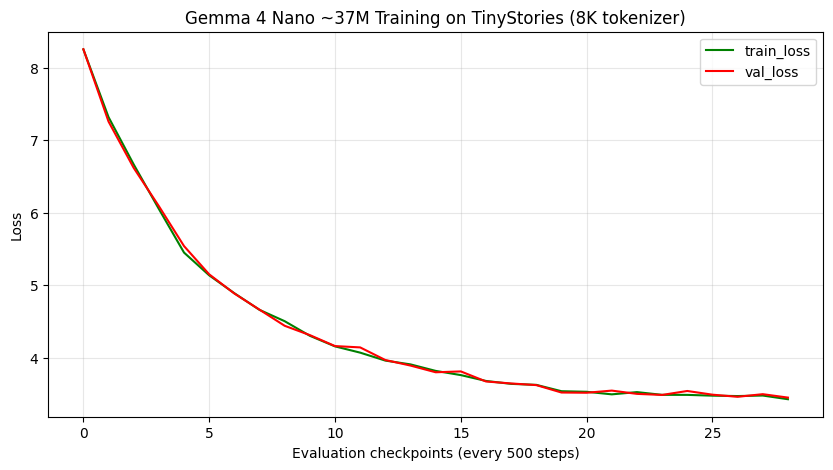

In [19]:
import matplotlib.pyplot as plt

train_cpu = [t.cpu().item() if torch.is_tensor(t) else float(t) for t in train_loss_list]
val_cpu = [v.cpu().item() if torch.is_tensor(v) else float(v) for v in val_loss_list]

plt.figure(figsize=(10, 5))
plt.plot(train_cpu, 'g', label='train_loss')
plt.plot(val_cpu, 'r', label='val_loss')
plt.xlabel(f"Evaluation checkpoints (every {eval_interval} steps)")
plt.ylabel("Loss")
plt.legend()
plt.title("Gemma 4 Nano ~37M Training on TinyStories (8K tokenizer)")
plt.grid(True, alpha=0.3)
plt.show()

## Step 16: Run Inference on the Trained Model

In [20]:
model = Gemma4Model(GEMMA4_CONFIG_54M)
model.load_state_dict(torch.load(best_model_path, map_location=torch.device(device)))
model = model.to(device)
model.eval()

prompts = [
    "Once upon a time there was a pumpkin.",
    "A little girl went to the woods",
    "Grandmother was telling the kids story about a unicorn",
]

for sentence in prompts:
    context = torch.tensor(enc.encode(sentence)).unsqueeze(0).to(device)
    y = model.generate(context, 200)
    print(f"\n{'='*60}")
    print(f"Prompt: {sentence}")
    print(f"{'='*60}")
    print(enc.decode(y.squeeze().tolist()))


Prompt: Once upon a time there was a pumpkin.
Once upon a time there was a pumpkin. A little girl named Sarah walked up to the shot her whisper whisper. She saw the pumpkin and Afterwards Afterwards, â€œWhat can do that, when something reached a alive. Would you like palm palm?â€ Sarah tricky creations creationss said â â â€œHello? I� pus the island island island canppies so ear, it looks so tasty! Iple dared dared together to make the palm palm palms over a skin skin and g g motorcycle motorcycle was chir chir reve pillows, garage, fascinated fascinated fascinated fascinated. He responsible responsible everyMeow, unwly. He could think flex meadow meadow meadow and esSurprise the spins spins out of the palm. He loved itm! He would get it for later to eat and enjoy enjoy the carpDid it fit in the sun. napkins and ow ow ball until it stopped. The simply simply simply burrowfliesflies and said goodbye with the palm palm palmœCanœCanœCanœCan quite look. The sun was shining down and the p